# Libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torchmetrics as tm
import torch.nn.functional as F
import seaborn as sns
torch.manual_seed(9497)
import scipy.stats as stats
import plotly.express as px
from pathlib import Path
import umap
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import multipletests
from scipy.stats import wilcoxon
import plotly.graph_objects as go
from matplotlib.colors import LinearSegmentedColormap

# Model 

In [2]:
from exp_regression import DrugAware_DWM, Transcriptomic_Head, SMILES_Head, CombinedModel
from cli_regressor import Module_training_reg
from utilities import CVDataModule

In [3]:
tx_head = Transcriptomic_Head(
            input_size=946, # 946 | 4377
            hd_1=512,
            hd_2=256
        )

chem_head = SMILES_Head(
    input_size=512,
    hd_1=512, 
    hd_2=256,
    hd_3=128
)

combined_model = CombinedModel(
    input_size=1024,
    hd_1=256, #256
    hd_2=128  #128
)

loss_fn = nn.MSELoss()
lr= 1e-4
wd=0.0

# Data

In [4]:
vector_smiles = pd.read_csv(
    "output/regression/vector_smiles_512.csv",
    index_col=0
)

In [5]:
vector_smiles.head()

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
Sunitinib,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
PHA-665752,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
Cyclopamine,0,0,0,0,0,0,0,1,0,0,...,1,0,1,0,0,1,1,0,0,0
AZ628,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
Imatinib,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1


## Cell lines

In [6]:
cline_gex = pd.read_csv(
    "output/regression/L1000_GEX_data_filtered_logCPM.csv",
    index_col=0
)

In [7]:
cline_gex.head()

,ABCB6,ABCC5,ABCF1,ABCF3,ABHD4,ABHD6,ABL1,ACAA1,ACAT2,ACBD3,...,ZMIZ1,ZMYM2,ZNF131,ZNF274,ZNF318,ZNF395,ZNF451,ZNF586,ZNF589,ZW10
model_name,,,,,,,,,,,,,,,,,,,,,
22RV1,6.692272,5.974217,5.972175,5.937373,3.905459,2.274118,6.491253,5.258903,6.844647,6.636650,...,4.987584,6.736658,5.452852,4.495404,6.299981,5.998490,6.188324,4.225246,4.699200,5.302827
23132-87,5.811651,5.621582,6.928492,5.869526,6.295594,3.886941,5.921526,5.789106,5.768256,5.802125,...,5.706728,6.679969,5.640479,4.667580,5.517527,5.866943,6.234096,3.788737,4.580018,5.407221
42-MG-BA,6.339612,4.853004,7.245003,5.280296,5.325799,4.142516,7.026414,5.161804,6.125542,6.124434,...,7.336627,4.794387,5.917842,5.280881,4.977325,5.281349,5.257054,2.324235,2.769024,5.603927
451Lu,5.219828,5.896027,6.377211,5.705629,4.042942,4.193596,5.952298,5.341295,5.092637,6.007741,...,6.561371,5.502658,4.866528,3.187331,5.518168,5.420912,4.847967,3.257737,4.093944,4.471016
5637,3.049106,4.826572,7.045027,5.333473,3.510659,1.870316,7.449089,5.054642,6.051388,5.287819,...,6.087544,5.290822,5.164975,4.105767,4.963710,6.145299,4.879865,3.134558,2.752614,5.516239


In [8]:
cline_annotation = pd.read_csv(
    "output/regression/dose_response_matrix.csv",
    index_col=0
)

/tmp/ipykernel_11056/1439493965.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  cline_annotation = pd.read_csv(


In [9]:
cline_annotation.head()

,CELL_LINE_NAME,TCGA_DESC,DRUG_NAME,PATHWAY_NAME,LN_IC50,PUTATIVE_TARGET
750,ES5,UNCLASSIFIED,Sunitinib,RTK signaling,3.773630,NaN
751,ES7,UNCLASSIFIED,Sunitinib,RTK signaling,2.990953,NaN
752,EW-11,UNCLASSIFIED,Sunitinib,RTK signaling,3.600300,NaN
753,SK-ES-1,UNCLASSIFIED,Sunitinib,RTK signaling,0.830185,NaN
754,COLO-829,SKCM,Sunitinib,RTK signaling,5.417977,NaN


## PDO benchmarking dataset

In [9]:
pdo_dataset = pd.read_csv(
    "data/validation_data/PDOs/integrated_data/pdo_logCPM.csv",
    index_col=0
)

In [11]:
pdo_dataset.head()

,ISG15,UBE2J2,C1orf159,TTLL10,ACAP3,CCNL2,ATAD3C,ATAD3B,ATAD3A,SSU72,...,NDUFB2-AS1,RLN2,SUGT1P1,TKTL1,MGAT3,RFX6,CALML5,DNAJB13,NPY1R,TAGAP
P9-M-LN,2.135407,5.956173,3.865369,0.000000,5.421376,6.602177,3.482956,4.871848,4.755832,6.345458,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
P20-T-G,5.641111,6.297789,3.801721,3.267579,5.367185,6.822650,4.496700,3.943341,4.824220,6.876626,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
P47-T-T,4.193460,7.046161,4.302859,1.287672,5.093846,6.931593,1.957051,5.513537,6.072567,7.356418,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
P47-R-AP,4.294714,6.575511,3.991047,1.164626,4.466613,6.575511,3.991047,5.001973,6.190251,7.365546,...,1.164626,1.164626,1.164626,1.164626,0.0,0.0,0.0,0.0,0.0,0.0
P48-M-LN,1.675951,3.582133,4.214310,6.718042,4.714022,6.940625,6.687640,5.260028,5.218100,7.418996,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
pdo_gex = pdo_dataset.loc[
    :,pdo_dataset.columns.intersection(cline_gex.columns)]
pdo_gex = pdo_gex.reindex(columns=cline_gex.columns, fill_value=0.0)
pdo_gex.shape

(54, 946)

In [11]:
pdo_dr = pd.read_csv(
    "data/validation_data/PDOs/integrated_data/dose_response_pdo.csv"
)

In [12]:
pdo_dr.head()

,Line,Drug,LogIC50,PATHWAY_NAME,seen_before,Lab,TCGA_DESC
0,P9-M-LN,Cisplatin,2.165619,DNA replication,yes,KK,HNSC
1,P20-T-G,Cisplatin,1.249902,DNA replication,yes,KK,HNSC
2,P47-T-T,Cisplatin,1.047319,DNA replication,yes,KK,HNSC
3,P47-R-AP,Cisplatin,1.420696,DNA replication,yes,KK,HNSC
4,P48-M-LN,Cisplatin,1.667707,DNA replication,yes,KK,HNSC


# HNSCC

In [13]:
pdo_dr["Y_TRUE"] = (
    pdo_dr.groupby("Line")["LogIC50"]
    .transform(lambda x: stats.zscore(x, nan_policy="omit"))
)

In [14]:
pdo_dr = pdo_dr.loc[pdo_dr.seen_before=="yes",:]

In [15]:
gdsc_smiles = pd.read_csv(
    "output/regression/vector_smiles_512.csv",
    index_col=0
)

gdsc_smiles.head()

,0,1,2,3,4,5,6,7,8,9,...,502,503,504,505,506,507,508,509,510,511
Sunitinib,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
PHA-665752,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
Cyclopamine,0,0,0,0,0,0,0,1,0,0,...,1,0,1,0,0,1,1,0,0,0
AZ628,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
Imatinib,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1


In [16]:
cline_annotation.DRUG_NAME[cline_annotation.DRUG_NAME=="torin2"] = "Torin 2"

/tmp/ipykernel_11056/1966417195.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  cline_annotation.DRUG_NAME[cline_annotation.DRUG_NAME=="torin2"] = "Torin 2"
/tmp/ipykernel_11056/1966417195.py:1: SettingWithCopyWarning: 
A value is trying

In [17]:

root = "output/regression/cross_validation"
cancer_type = "pancancer" # pancancer , solid_tumors
experiment = "NBS_cells"

fold_dirs = Path(f"{root}/{cancer_type}/{experiment}/")
ckpt_dir = Path(f"cDWM/L1000_{cancer_type}_NBS_cells/")

# Sort fold paths in numeric order (fold_0, fold_1, ...)
folds = sorted(fold_dirs.glob("fold_*"), key=lambda x: int(x.name.split("_")[1]))
ckpts = sorted(ckpt_dir.glob("version_*"), key=lambda x: int(x.name.split("_")[1]))

cv_dr_l = []
w_l = []


for fold_path, ckpt_path in zip(folds, ckpts):
    fold_name = fold_path.name.split("_")[1]
    ckpt_file = list((ckpt_path / 'checkpoints').glob('*.ckpt'))[0]

    regressor = Module_training_reg.load_from_checkpoint(
    ckpt_file,
    map_location="cpu",
    tx_nn=tx_head,
    chem_nn=chem_head,
    comb_nn=combined_model,
    loss_fn=loss_fn,
    lr=lr,
    weight_decay=wd
    )

    data_module = CVDataModule(
        root = root,
        type = cancer_type,
        experiment = experiment,
        fold_n = fold_name,
        GEX_path = "output/regression/L1000_GEX_data_filtered_logCPM.csv",
        SMILES_path = "output/regression/vector_smiles_512.csv",
        batch_size = 512,
        num_workers = 12
    )


    data_module.setup()

    ########################################
    #
    # SUBSETTING TO LINE-DRUG PAIRS
    #
    ########################################
    train_mean = torch.tensor(data_module.gex_mean.to_numpy(), dtype=torch.float32)
    train_std = torch.tensor(data_module.gex_std.to_numpy(), dtype=torch.float32)

    drugs = cline_annotation.DRUG_NAME.unique()
    
    drug_combination = (
    pd.DataFrame({"Line": pdo_gex.index})
    .merge(pd.DataFrame({"Drug": drugs}), how="cross")
    )
    
    gex = torch.tensor(
        pdo_gex.loc[drug_combination.Line,:].to_numpy(), dtype=torch.float32
    )
    
    sm = torch.tensor(
        gdsc_smiles.loc[drug_combination.Drug, :].to_numpy(), dtype=torch.float32
    )

    gex = (gex - train_mean)/train_std
    
    #----STANDARD PREDICTION----
    y_hat = regressor.predict(
        gex=gex,
        sm=sm
    )
    
    y_hat = y_hat.double()
    y_hat = y_hat.numpy()
    drug_combination["Y_HAT"] = y_hat
    drug_combination["fold_n"] = fold_name

    #---- SMILES ----
    sm_emb = (
        regressor
        .chem_nn
        .predict(sm)
    )

    #---- GEX ----
    # gex_emb = (
    #     regressor
    #     .tx_nn
    #     .predict(gex, sm_emb, mode="predict")
    # )

    #---- Weight matrix ----
    _ , W = (
        regressor
        .tx_nn
        .predict(gex, sm_emb, mode="exploratory")
    )

    #---- Append to list ----

    # combined_emb = pd.DataFrame(
    #     gex_emb.numpy() + sm_emb.numpy(),
    #     index = pd.MultiIndex.from_frame(
    #         pdo_dr.loc[:,["Line", "Drug", "PATHWAY_NAME", "Lab", "TCGA_DESC"]]
    #     )
    # )
    # combined_l.append(combined_emb)

    W = pd.DataFrame(
        W.numpy(),
        index = pd.MultiIndex.from_frame(
            drug_combination.loc[:,["Line", "Drug", "fold_n"]]
        )
    )
    w_l.append(W)

    cv_dr_l.append(drug_combination)

    

In [18]:
dr_pred = pd.concat(
    cv_dr_l,
    axis=0
)

dr_pred = (
    dr_pred
    .groupby(["Line", "Drug"], as_index=False)
    .median("Y_HAT")
)

dr_pred.head()

,Line,Drug,Y_HAT
0,G61-M-LN,(5Z)-7-Oxozeaenol,-0.718554
1,G61-M-LN,5-Fluorouracil,1.077253
2,G61-M-LN,5-azacytidine,0.376634
3,G61-M-LN,A-366,1.041171
4,G61-M-LN,A-443654,-1.222239


In [19]:
from scipy.stats import skew, kurtosis

In [20]:
def bimodality_coefficient(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = x.size
    if n < 8:
        return np.nan  # too small to be meaningful

    # skewness (Fisher-Pearson, bias-corrected)
    g = skew(x, bias=False)

    # kurtosis: Pearson kurtosis (NOT excess), bias-corrected
    k_excess = kurtosis(x, fisher=True, bias=False)
    k = k_excess + 3.0

    # small-sample correction term
    c = (3.0 * (n - 1)**2) / ((n - 2) * (n - 3))

    return (g**2 + 1.0) / (k + c)

In [21]:
dr_pred["BC"]=(
    dr_pred.groupby("Drug")["Y_HAT"]
    # .apply(lambda s: bimodality_coefficient(s.values))
    .transform(lambda s: bimodality_coefficient(s.values))
)

In [22]:
tcga_desc = (
    dr_pred.Line
    .map(
        pdo_dr
        .drop_duplicates("Line")
        .set_index("Line")["TCGA_DESC"]
    )
)

In [23]:
dr_pred["TCGA_DESC"] = tcga_desc

In [24]:
hnsc_dr = dr_pred.loc[dr_pred.TCGA_DESC=="HNSC",:]
hnsc_dr.head()

,Line,Drug,Y_HAT,BC,TCGA_DESC
0,G61-M-LN,(5Z)-7-Oxozeaenol,-0.718554,0.247301,HNSC
1,G61-M-LN,5-Fluorouracil,1.077253,0.197492,HNSC
2,G61-M-LN,5-azacytidine,0.376634,0.210204,HNSC
3,G61-M-LN,A-366,1.041171,0.181274,HNSC
4,G61-M-LN,A-443654,-1.222239,0.277118,HNSC


In [25]:
pathway = (
    hnsc_dr.Drug
    .map(
        cline_annotation
        .drop_duplicates("DRUG_NAME")
        .set_index("DRUG_NAME")["PATHWAY_NAME"]
    )
)

hnsc_dr["PATHWAY_NAME"] = pathway

/tmp/ipykernel_11056/67626180.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hnsc_dr["PATHWAY_NAME"] = pathway


In [ ]:
mat_dr = hnsc_dr

In [ ]:
mat_dr.head()

In [32]:
mat_dr = (mat_dr
          .pivot_table(
              columns="Line",
              index="PATHWAY_NAME",
              values="Y_HAT",
              aggfunc="mean",
              fill_value=0.0
              )
)

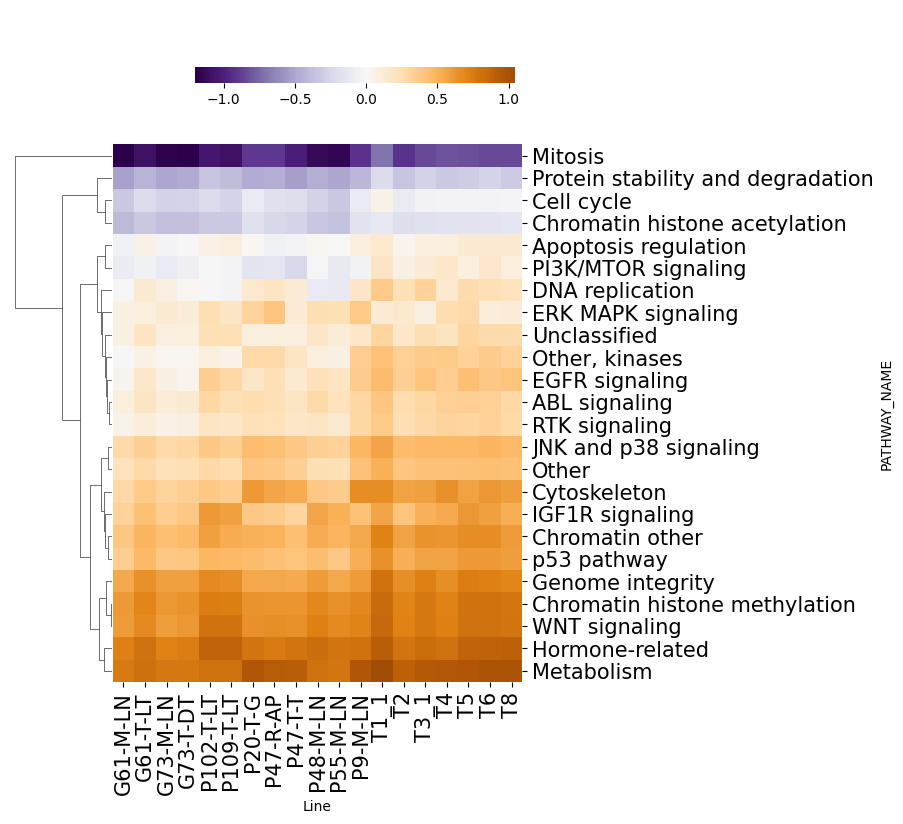

In [57]:
g = sns.clustermap(mat_dr,
                   row_cluster=True,
                   col_cluster=False,
                   cmap="PuOr_r", #seismic
                   standard_scale=None,
                   z_score=None,
                   center=0,
                   method="average",
                   metric="euclidean",
                   figsize=(8, 8),
                   cbar_kws={"orientation": "horizontal"},
                   cbar_pos=(0.25, 0.89, 0.4, 0.02)
                   #col_colors=drug_class_colors
              )

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=15)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=15)
# g.savefig("slides/figures_regression/drug_response/DR_heatmap_tcga_pathway.pdf", dpi=600)
g

In [58]:
# g.fig.savefig(
#     "slides/figures_regression/drug_recommendation/predicted_IC50_clustermap.pdf",
#     format="pdf",
#     bbox_inches="tight",
#     dpi=600
# )

## Drug recommendation

In [26]:
ranking = hnsc_dr.copy()

In [27]:
ranking = (
    ranking
    .set_index(["Line","Drug"])["Y_HAT"]
    .groupby(level="Line")
    .apply(lambda x: x[x <= x.quantile(0.25)])
    .droplevel(0)
).to_frame().reset_index()

In [28]:
ranking["rank"] = (
    ranking
    .groupby("Line")["Y_HAT"]
    .rank(method="first", ascending=True)
)

In [29]:
ranking["n_drugs_line"] = (
    ranking
    .groupby("Line")["Drug"]
    .transform("count")
)

In [30]:
# Percentile rank #
# Linear normalization of ranks to be bounded between 0-1, 1 being the best.
ranking["pct_rank"] = 1- (ranking["rank"]-1) /(ranking["n_drugs_line"]-1)

In [31]:
ranking.head()

,Line,Drug,Y_HAT,rank,n_drugs_line,pct_rank
0,G61-M-LN,(5Z)-7-Oxozeaenol,-0.718554,72.0,103,0.303922
1,G61-M-LN,A-443654,-1.222239,44.0,103,0.578431
2,G61-M-LN,A-770041,-0.619309,82.0,103,0.205882
3,G61-M-LN,ACY-1215,-0.529664,91.0,103,0.117647
4,G61-M-LN,AR-42,-1.463124,32.0,103,0.696078


In [32]:
ranking = (
    ranking
    .join(hnsc_dr
          .set_index("Drug")
          .loc[:,["BC","PATHWAY_NAME"]], on="Drug")
)

In [33]:
ranking = ranking.drop_duplicates(["Line", "Drug"])

In [34]:
ranking["pair"] = ranking["Line"].str.cat(ranking["Drug"], sep="~~")

In [35]:
import plotly.graph_objects as go

In [36]:
ranking = ranking.assign(
    BC_group = np.where(ranking["BC"] >= 0.3, "BC ≥ 0.3", "BC < 0.3")
)

fig = px.scatter(
    ranking,
    x="BC",
    y="pct_rank",
    color="BC_group",
    color_discrete_map={
        "BC < 0.3": "lightgrey",
        "BC ≥ 0.3": "red",
    },
    width=900,
    height=700,
    template="simple_white",
    hover_data=["pair", "Y_HAT"],
    labels={
        "pct_rank" : "Rank",
        "BC" : "Selectivity"
    }
)

fig.update_layout(
    font=dict(size=16),
)

fig.update_traces(
    marker=dict(
        size=8,
        line=dict(width=1, color="DarkSlateGrey")
    )
)


# fig.add_trace(
#     go.Histogram2dContour(
#         x=ranking["BC"],
#         y=ranking["pct_rank"],
#         colorscale="Greys",
#         # opacity=0.4,
#         showscale=False,
#         contours=dict(showlines=False),
#     )
# )


fig.add_vline(
    x=0.3,
    line_width=2,
    line_dash="dash",
    line_color="black",
)



fig

In [152]:
# fig.write_image(
#     "slides/figures_regression/drug_recommendation/rank_vs_BC.pdf"
# )

In [73]:
drug_status = [
    # --- FDA approved ---
    ("Belinostat", "FDA approved"),
    ("Bortezomib", "FDA approved"),
    ("Dactinomycin", "FDA approved"),
    ("Dasatinib", "FDA approved"),
    ("Docetaxel", "FDA approved"),
    ("Doxorubicin", "FDA approved"),
    ("Epirubicin", "FDA approved"),
    ("Gemcitabine", "FDA approved"),
    ("Methotrexate", "FDA approved"),
    ("Midostaurin", "FDA approved"),
    ("Mitomycin-C", "FDA approved"),
    ("Paclitaxel", "FDA approved"),
    ("Panobinostat", "FDA approved"),
    ("Ponatinib", "FDA approved"),
    ("Rapamycin", "FDA approved"),
    ("Romidepsin", "FDA approved"),
    ("Trametinib", "FDA approved"),
    ("Vinblastine", "FDA approved"),
    ("Vinorelbine", "FDA approved"),
    ("Vorinostat", "FDA approved"),
    ("Venetoclax", "FDA approved"),
    ("Temsirolimus", "FDA approved"),
    ("Topotecan", "FDA approved"),
    ("Osimertinib", "FDA approved"),
    ("Cabozantinib", "FDA approved"),
    ("Tivozanib", "FDA approved"),
    ("Quizartinib", "FDA approved"),
    ("Etoposide", "FDA approved"),
    ("Teniposide", "FDA approved"),

    # --- Clinical (documented clinical trials, no FDA approval) ---
    ("ACY-1215", "Clinical"),
    ("AR-42", "Clinical"),
    ("ARRY-520", "Clinical"),
    ("AT-7519", "Clinical"),
    ("AZD7762", "Clinical"),
    ("AZD8055", "Clinical"),
    ("Apitolisib", "Clinical"),
    ("BI-2536", "Clinical"),
    ("Bryostatin 1", "Clinical"),
    ("Buparlisib", "Clinical"),
    ("CUDC-101", "Clinical"),
    ("Dacinostat", "Clinical"),
    ("Dactolisib", "Clinical"),
    ("Dinaciclib", "Clinical"),
    ("Elesclomol", "Clinical"),
    ("Fedratinib", "Clinical"),
    ("Flavopiridol", "Clinical"),
    ("Foretinib", "Clinical"),
    ("I-BET-151", "Clinical"),
    ("Ispinesib Mesylate", "Clinical"),
    ("Lestaurtinib", "Clinical"),
    ("Luminespib", "Clinical"),
    ("MK-1775", "Clinical"),
    ("Obatoclax Mesylate", "Clinical"),
    ("Omipalisib", "Clinical"),
    ("PD0325901", "Clinical"),
    ("PF-00299804", "Clinical"),
    ("PHA-793887", "Clinical"),
    ("Pelitinib", "Clinical"),
    ("SNX-2112", "Clinical"),
    ("Tanespimycin", "Clinical"),
    ("Tipifarnib", "Clinical"),
    ("Taselisib", "Clinical"),
    ("Navitoclax", "Clinical"),
    ("CI-1040", "Clinical"),
    ("Refametinib", "Clinical"),

    # --- Investigational / preclinical / tool compounds ---
    ("(5Z)-7-Oxozeaenol", "Investigational"),
    ("A-443654", "Investigational"),
    ("A-770041", "Investigational"),
    ("AZ20", "Investigational"),
    ("AZ628", "Investigational"),
    ("AZD4877", "Investigational"),
    ("CAY10603", "Investigational"),
    ("CCT245232", "Investigational"),
    ("CD532", "Investigational"),
    ("CGP-60474", "Investigational"),
    ("CP466722", "Investigational"),
    ("Camptothecin", "Investigational"),
    ("Daporinad", "Investigational"),
    ("Dihydrorotenone", "Investigational"),
    ("Epothilone B", "Investigational"),
    ("GNE-317", "Investigational"),
    ("GSK1059615", "Investigational"),
    ("GSK1070916", "Investigational"),
    ("GW843682X", "Investigational"),
    ("HG6-64-1", "Investigational"),
    ("IMD-0354", "Investigational"),
    ("JW-7-24-1", "Investigational"),
    ("LDN-193189", "Investigational"),
    ("LMP744", "Investigational"),
    ("MG-132", "Investigational"),
    ("NG-25", "Investigational"),
    ("NSC319726", "Investigational"),
    ("NVP-BHG712", "Investigational"),
    ("NVP-TAE684", "Investigational"),
    ("PI-103", "Investigational"),
    ("PIK-93", "Investigational"),
    ("Podophyllotoxin bromide", "Investigational"),
    ("QL-X-138", "Investigational"),
    ("SN-38", "Investigational"),
    ("Sabutoclax", "Investigational"),
    ("Sepantronium bromide", "Investigational"),
    ("Shikonin", "Investigational"),
    ("Staurosporine", "Investigational"),
    ("TPCA-1", "Investigational"),
    ("Telomerase Inhibitor IX", "Investigational"),
    ("Thapsigargin", "Investigational"),
    ("Torin 2", "Investigational"),
    ("Trichostatin A", "Investigational"),
    ("WH-4-023", "Investigational"),
    ("WYE-125132", "Investigational"),
    ("WZ3105", "Investigational"),
    ("YM201636", "Investigational"),
    ("Z-LLNle-CHO", "Investigational"),
    ("ZG-10", "Investigational"),
    ("ZSTK474", "Investigational"),
    ("AZD1480", "Investigational"),
    ("S-Trityl-L-cysteine", "Investigational"),
    ("Saracatinib", "Investigational"),
    ("Pictilisib", "Investigational"),
    ("BAY-61-3606", "Investigational"),
    ("CX-5461", "Investigational"),
    ("NPK76-II-72-1", "Investigational"),
    ("OSU-03012", "Investigational"),
    ("AZD2014", "Investigational"),
    ("POMHEX", "Investigational"),
    ("Schweinfurthin A", "Investigational"),
    ("TW 37", "Investigational"),
    ("UNC0642", "Investigational"),
    ("ABT737", "Investigational"),
    ("Afuresertib", "Investigational"),
    ("CI-1033", "Investigational"),
    ("HG-5-113-01", "Investigational"),
    ("SCH772984", "Investigational"),
    ("FH535", "Investigational"),
    ("PF-562271", "Investigational"),
    ("FTI-277", "Investigational"),
]

drug_status = pd.DataFrame(drug_status, columns=["Drug", "Status"])
drug_status.Drug.nunique()

136

In [74]:
status_palette = {
    "FDA approved": "#D95F02",        # teal / green
    "Clinical": "#6A51A3",        # violet
    "Investigational": "#D3D3D3" #"#6E6E6E"  # neutral dark gray
}

color = drug_status.set_index("Drug")["Status"].map(status_palette)


In [178]:
heat = (ranking
        .pivot_table(
            index="Line",
            columns="Drug",
            values="pct_rank",
            aggfunc="mean"
        )
        .fillna(-1)
       )

In [75]:
# filtering for only selective drugs

heat = (
    ranking.loc[ranking.BC>=0.3,:]
    .pivot_table(
        index="Line",
        columns="Drug",
        values="pct_rank",
        aggfunc="mean"
    )
    .fillna(-1)
)

In [ ]:
drug_status = drug_status.loc[
drug_status.Status.isin(["FDA approved", "Clinical"]),:
]

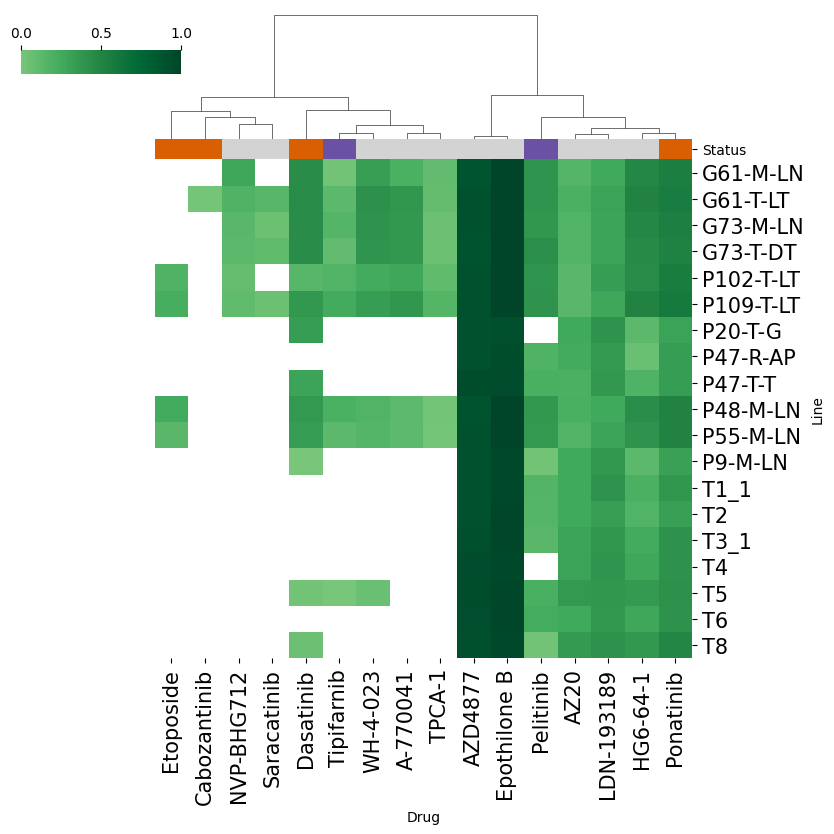

In [76]:
# cmap = plt.cm.PuOr_r.copy()
# cmap.set_under("lightgrey")   # color for NaN

heat = heat.loc[:,heat.columns.isin(drug_status.Drug)]
g = sns.clustermap(
    heat,
    row_cluster=False,
    col_cluster=True,
    cmap="YlGn",
    standard_scale=None,
    mask=heat.eq(-1),
    z_score=None,
    center=0,
    method="ward",
    metric="euclidean",
    figsize=(8, 8),
    cbar_kws = dict(use_gridspec=False,location="top"),
    cbar_pos=(0.02, 0.90, 0.2, 0.03),
    col_colors=color,
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=15)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=15)
# g.ax_heatmap.xaxis.set_visible(False)
g

In [186]:
# g.fig.savefig(
#     "slides/figures_regression/drug_recommendation/Q25_recomendation_clustermap.pdf",
#     format="pdf",
#     bbox_inches="tight",
#     dpi=600
# )

In [193]:
# g.fig.savefig(
#     "slides/figures_regression/drug_recommendation/Q25_recomendation_selective_clustermap.pdf",
#     format="pdf",
#     bbox_inches="tight",
#     dpi=600
# )

In [252]:
export_table = (
    ranking
    .loc[ranking.BC>=0.3,:]
    .loc[~ranking.Line.str.startswith("T"),:]
    .sort_values("pct_rank", ascending=False)
    .iloc[:,0:8]
    .loc[ranking.Drug.isin(drug_status.Drug),:]
    
)

In [253]:
export_table["Drug_status"]=(
    export_table["Drug"]
    .map(
        drug_status.set_index("Drug")["Status"]
    )
)

In [254]:
drug_status.Drug.nunique()

65

In [255]:
export_table.Drug.nunique()

6

In [256]:
# export_table.to_csv(
#     "output/drug_recomendation/selective_drug_recomendation.csv",
#     index=False
# )

In [261]:
# (
#     export_table
#     .loc[export_table.Line.str.startswith(("P47","G73","G61")),:]
#     .to_csv(
#         "output/drug_recomendation/match_samples_selective_drug_recomendation.csv",
#         index=False
#     )
# )

## Weight matrix

In [37]:
W = pd.concat(
    w_l,
    axis=0
)

W.head()

0         1         2         3         4    \
Line    Drug        fold_n                                                     
P9-M-LN Sunitinib   0       0.911491  0.033463  0.000197  0.001081  0.001117   
        PHA-665752  0       0.074931  0.466053  0.131185  0.000130  0.003255   
        Cyclopamine 0       0.254813  0.004250  0.055675  0.001090  0.000041   
        AZ628       0       0.987580  0.799792  0.003574  0.004366  0.392852   
        Imatinib    0       0.166484  0.510824  0.027649  0.000263  0.119614   

                                 5         6         7         8         9    \
Line    Drug        fold_n                                                     
P9-M-LN Sunitinib   0       0.994592  0.771909  0.974395  0.096588  0.055672   
        PHA-665752  0       0.187281  0.120245  0.649049  0.000357  0.000809   
        Cyclopamine 0       0.596098  0.338694  0.393350  0.000725  0.000690   
        AZ628       0       0.164474  0.726080  0.918212  0.048388  0.005973   
        Imatinib    0       0.130746  0.266785  0.073677  0.000673  0.015115   

                            ...       936       937       938       939  \
Line    Drug        fold_n  ...                                           
P9-M-LN Sunitinib   0       ...  0.001050  0.056604  0.000013  0.004540   
        PHA-665752  0       ...  0.895082  0.044214  0.000402  0.009976   
        Cyclopamine 0       ...  0.639189  0.315566  0.000098  0.106114   
        AZ628       0       ...  0.010029  0.021970  0.009707  0.489308   
        Imatinib    0       ...  0.957287  0.122755  0.001494  0.002834   

                                 940       941       942       943       944  \
Line    Drug        fold_n                                                     
P9-M-LN Sunitinib   0       0.001068  0.000176  0.003504  0.000026  0.602729   
        PHA-665752  0       0.000525  0.011024  0.211724  0.016279  0.022744   
        Cyclopamine 0       0.007254  0.000577  0.105354  0.000973  0.214177   
        AZ628       0       0.000900  0.004095  0.010014  0.000077  0.072532   
        Imatinib    0       0.001139  0.020031  0.120540  0.048768  0.014009   

                                 945  
Line    Drug        fold_n            
P9-M-LN Sunitinib   0       0.091736  
        PHA-665752  0       0.008839  
        Cyclopamine 0       0.030855  
        AZ628       0       0.037943  
        Imatinib    0       0.005590  

[5 rows x 946 columns]

In [38]:
tcga_desc = (
    W.index.get_level_values("Line")
    .map(
        pdo_dr
        .drop_duplicates("Line")
        .set_index("Line")["TCGA_DESC"]
    )
)

In [39]:
W = pd.concat([W], keys=tcga_desc.to_list(), names=["TCGA_DESC"])

/tmp/ipykernel_11056/1477086927.py:1: FutureWarning:

The behavior of pd.concat with len(keys) != len(objs) is deprecated. In a future version this will raise instead of truncating to the smaller of the two sequences



In [40]:
hnsc_W = W.xs("HNSC", level="TCGA_DESC")

In [41]:
hnsc_W.columns = cline_gex.columns

In [42]:
low25_drug = (
    hnsc_dr
    .set_index(["Line","Drug"])["Y_HAT"]
    .groupby(level="Line")
    .apply(lambda x: x[x <= x.quantile(0.25)])
    .droplevel(0)
    .index
)

In [43]:

hnsc_low25 = hnsc_W.loc[hnsc_W.index.isin(low25_drug),:]


In [44]:
hnsc_low25 = (
    hnsc_low25
    .groupby(["Line", "Drug"])
    .median()
)

In [196]:
# binomial_drugs = (
#     pd.MultiIndex.from_frame(
#         ranking.loc[ranking.BC>=0.3,["Line", "Drug"]]
#     )
# )
# hnsc_low25 = hnsc_low25.loc[hnsc_low25.index.intersection(binomial_drugs)]

In [45]:
hnsc_low25 = (
    hnsc_low25
    .groupby(["Line"])
    .median()
)

In [46]:
hc = (
    hnsc_low25.loc[hnsc_low25.index.str.startswith("T"),:]
)

hc = (hc-hc.mean(0))/hc.std(0)

kk = (
    hnsc_low25.loc[~hnsc_low25.index.str.startswith("T"),:]
)

kk = (kk-kk.mean(0))/kk.std(0)

hnsc_low25 = pd.concat([kk,hc])

hnsc_low25 = hnsc_low25.apply(pd.to_numeric)

In [47]:
upper25_drug = (
    hnsc_dr
    .set_index(["Line","Drug"])["Y_HAT"]
    .groupby(level="Line")
    .apply(lambda x: x[x >= x.quantile(0.75)])
    .droplevel(0)
    .index
)

hnsc_upper25 = hnsc_W.loc[hnsc_W.index.isin(upper25_drug),:]

hnsc_upper25 = (
    hnsc_upper25
    .groupby(["Line", "Drug"])
    .median()
)

hnsc_upper25 = (
    hnsc_upper25
    .groupby(["Line"])
    .median()
)

In [48]:
hc = (
    hnsc_upper25.loc[hnsc_upper25.index.str.startswith("T"),:]
)

hc = (hc-hc.mean(0))/hc.std(0)

kk = (
    hnsc_upper25.loc[~hnsc_upper25.index.str.startswith("T"),:]
)

kk = (kk-kk.mean(0))/kk.std(0)

hnsc_upper25 = pd.concat([kk,hc])

hnsc_upper25 = hnsc_upper25.apply(pd.to_numeric)

In [49]:
hnsc_upper25 = hnsc_upper25 - hnsc_low25
hnsc_low25 = hnsc_low25 - hnsc_upper25

In [51]:
dot_plot = (
    hnsc_upper25
    .reset_index()
    .melt(
        id_vars="Line",
        var_name="Gene",
        value_name="W",
    )
)

In [136]:
# dot_plot = res.res2d
dot_plot["W"] = dot_plot["W"].astype("float64")
dot_plot = (
    dot_plot
    .sort_values("W", ascending=False)
    .groupby(["Line"])
    .head(10)
)


In [ ]:
########################################
#  MATCHED SAMPLES
########################################


up_patient = dot_plot.loc[dot_plot.Line.str.contains("P47|G61|G73")]


fig = px.scatter(
    up_patient,
    x="Gene",
    y="Line",
    template="simple_white",
    size=up_patient.W.abs(), # Drug
    color="W", # Drug
    # range_color=(low25_line.Y_HAT.min(), low25_line.Y_HAT.max()),
    color_continuous_scale=px.colors.sequential.Oranges, #Blues
    # range_color=(0, 2),
    width=1500,
    height=500,
    hover_data=[up_patient.Gene],
    labels={
        "Line": "",
        "Gene": "",
        "W":""
    },
    category_orders={
        "Line": [
            "G61-T-LT","G61-M-LN",
            "G73-T-DT","G73-M-LN",
            "P47-T-T","P47-R-AP"
        ]
    }
)

fig.update_traces(
    marker=dict(
        line=dict(width=1, color="DarkSlateGrey"),
    )
)

fig.update_layout(
    font=dict(size=16),
)

fig.update_xaxes(
    tickangle=270,
    side="top"
)

fig.update_xaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor="rgba(0,0,0,0.08)",  # plotly_white-like
    tickangle=270
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor="rgba(0,0,0,0.08)"
)

In [53]:
import gseapy as gp

#### Upper 25

#### ssGSEA

In [521]:
res = gp.ssgsea(
    data=hnsc_upper25.T,
    gene_sets="GMTs/h.all.v2025.1.Hs.symbols.gmt",
    sample_norm_method="rank",   # common default; ssGSEA is rank-based
    outdir=None,                 # no files written
    permutation_num=0,           # keep 0 for ssGSEA (per docs warning)
    threads=10,
)

In [522]:
heatmap = (
    res.res2d
    .pivot_table(
        values="NES",
        index="Name",
        columns="Term"
    )
)

In [523]:
heatmap = heatmap.apply(pd.to_numeric)

In [524]:
heatmap = (heatmap-heatmap.mean(0))/heatmap.std(0)

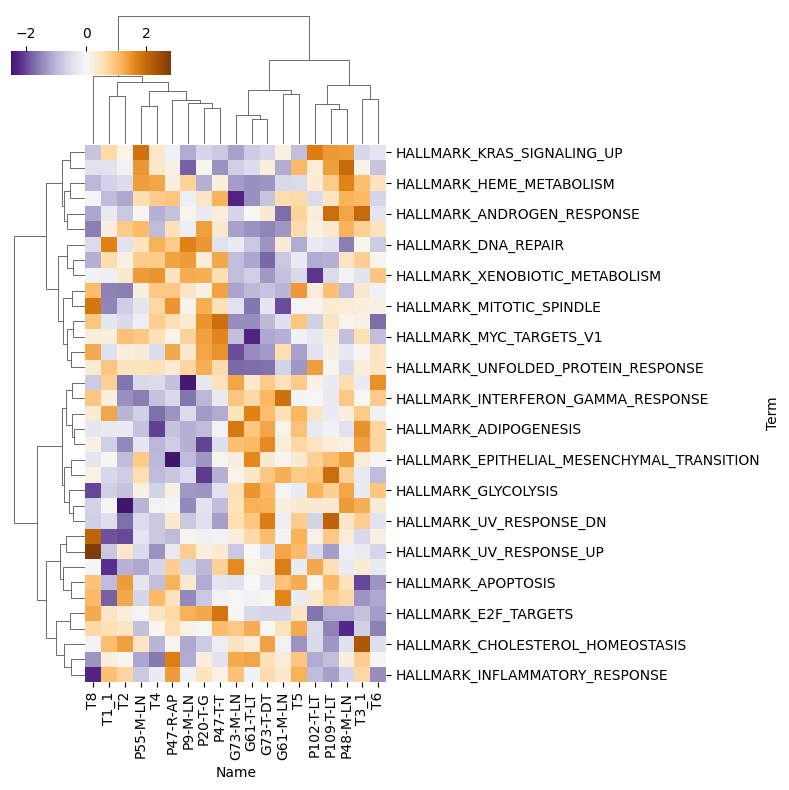

In [525]:
g = sns.clustermap(
    heatmap.T,
    # heatmap.loc[heatmap.index.str.contains("P47|G61|G73"),:].T,
    row_cluster=True,
    col_cluster=True,
    cmap="PuOr_r", #seismic
    standard_scale=None,
    z_score=None,
    center=0,
    method="ward",
    metric="euclidean",
    figsize=(8, 8),
    cbar_kws = dict(use_gridspec=False,location="top"),
    cbar_pos=(0.02, 0.90, 0.2, 0.03),
    # col_colors=color,
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=10)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=10)
# g.ax_heatmap.xaxis.set_visible(False)
g

In [79]:
# g.fig.savefig(
#     "slides/figures_regression/weight_matrix_analysis/ssGSEA_Q75_heatmap_diff.pdf",
#     format="pdf",
#     bbox_inches="tight",
#     dpi=600
# )

In [496]:
dot_plot = (
    heatmap
    .reset_index()
    .melt(
        id_vars="Name",
        var_name="Term",
        value_name="NES",
    )
)

In [497]:
# dot_plot = res.res2d
dot_plot["NES"] = dot_plot["NES"].astype("float64")
dot_plot = (
    dot_plot
    .sort_values("NES", ascending=False)
    .groupby(["Name"])
    .head(10)
)


In [ ]:
fig = px.scatter(
    dot_plot,
    x=dot_plot.Term.str.removeprefix("GOBP_"),
    y="Name",
    template="simple_white",
    size=dot_plot.NES.abs(), # Drug
    color="NES", # Drug
    # range_color=(low25_line.Y_HAT.min(), low25_line.Y_HAT.max()),
    color_continuous_scale=px.colors.sequential.Oranges, #Blues
    range_color=(0, 2),
    width=1100,
    height=1100,
    hover_data=["Term"],
    labels={
        "Name": "",
        "Term": "",
        "x":""
    }
)

fig.update_traces(
    marker=dict(
        line=dict(width=1, color="DarkSlateGrey"),
    )
)

fig.update_layout(
    font=dict(size=16),
)

fig.update_xaxes(
    tickangle=270,
    side="top"
)

fig.update_xaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor="rgba(0,0,0,0.08)",  # plotly_white-like
    tickangle=270
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor="rgba(0,0,0,0.08)"
)

In [498]:
########################################
#  MATCHED SAMPLES
########################################


up_patient = dot_plot.loc[dot_plot.Name.str.contains("P47|G61|G73")]


fig = px.scatter(
    up_patient,
    x=up_patient.Term.str.removeprefix("HALLMARK_"),
    y="Name",
    template="simple_white",
    size=up_patient.NES.abs(), # Drug
    color="NES", # Drug
    # range_color=(low25_line.Y_HAT.min(), low25_line.Y_HAT.max()),
    color_continuous_scale=px.colors.sequential.Oranges, #Blues
    range_color=(0, 2),
    width=1000,
    height=800,
    hover_data=["Term"],
    labels={
        "Name": "",
        "Term": "",
        "x":""
    },
    category_orders={
        "Name": [
            "G61-T-LT","G61-M-LN",
            "G73-T-DT","G73-M-LN",
            "P47-T-T","P47-R-AP"
        ]
    }
)

fig.update_traces(
    marker=dict(
        line=dict(width=1, color="DarkSlateGrey"),
    )
)

fig.update_layout(
    font=dict(size=16),
)

fig.update_xaxes(
    tickangle=270,
    side="top"
)

fig.update_xaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor="rgba(0,0,0,0.08)",  # plotly_white-like
    tickangle=270
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor="rgba(0,0,0,0.08)"
)

In [138]:
# fig.write_image(
#     "slides/figures_regression/weight_matrix_analysis/Q75_hallmarks_dotplot.pdf"
# )

In [206]:
# fig.write_image(
#     "slides/figures_regression/weight_matrix_analysis/Q75_matched-samples_reactome_dotplot.pdf"
# )

#### VIPER

In [50]:
import decoupler as dc

In [51]:
net = dc.op.collectri(license="academic")
# net = dc.op.progeny(organism="human")

In [52]:
res_viper, padj = dc.mt.viper(
    data = hnsc_upper25,
    net=net
)

<Axes: >

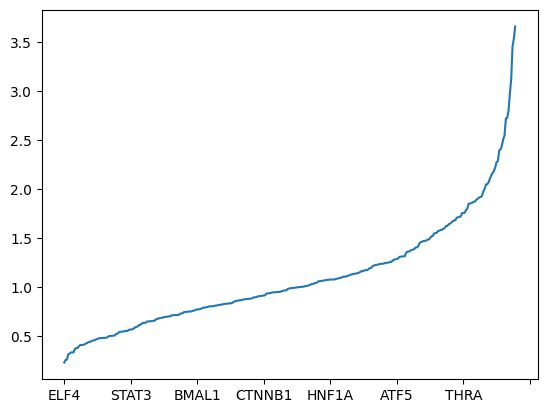

In [53]:
res_viper.var(0).sort_values().plot()

In [59]:
res_viper.var(0).describe()

count    340.000000
mean       1.097058
std        0.564952
min        0.232689
25%        0.716597
50%        0.987464
75%        1.312888
max        3.656170
dtype: float64

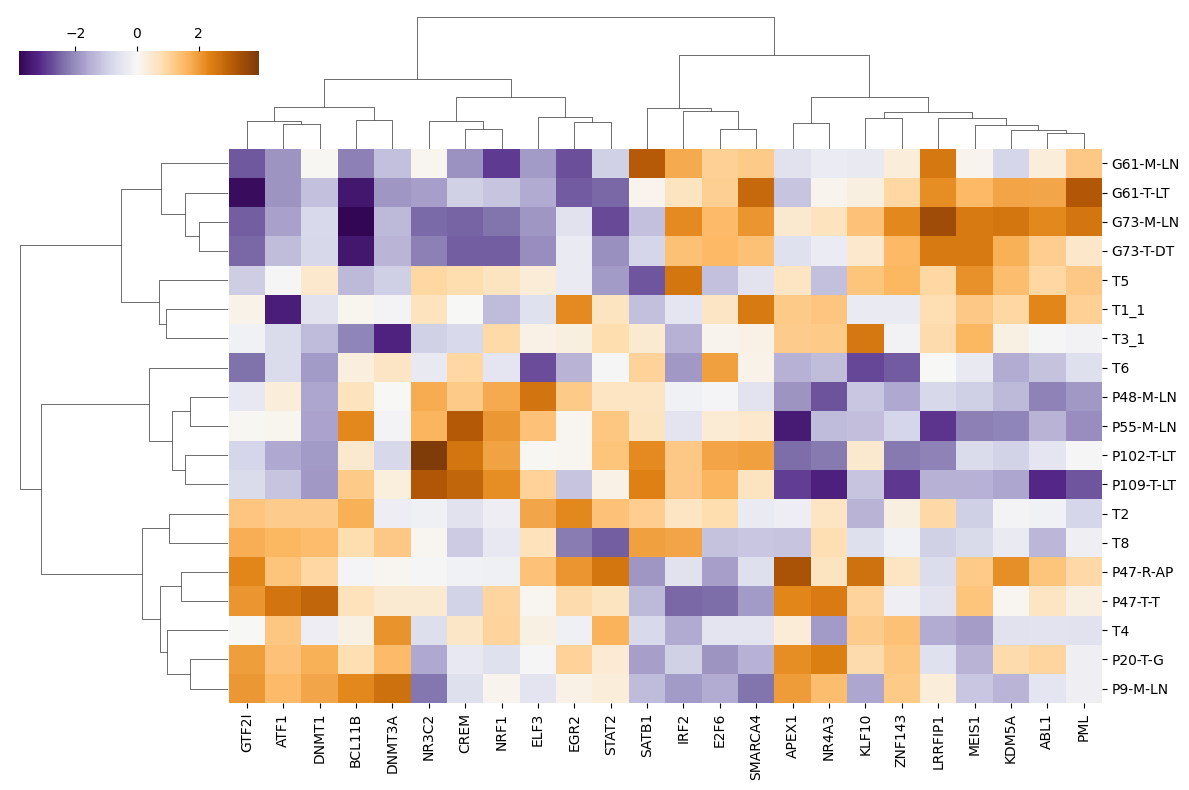

In [67]:
g = sns.clustermap(
    res_viper.loc[:,(res_viper.var(0)>2)],
    row_cluster=True,
    col_cluster=True,
    cmap="PuOr_r", #seismic
    standard_scale=None,
    z_score=None,
    center=0,
    method="ward",
    metric="euclidean",
    figsize=(12, 8),
    cbar_kws = dict(use_gridspec=False,location="top"),
    cbar_pos=(0.02, 0.90, 0.2, 0.03),
    # col_colors=color,
)

In [70]:
# g.fig.savefig(
#     "slides/figures_regression/weight_matrix_analysis/VIPER_Q75_heatmap_diff.pdf",
#     format="pdf",
#     bbox_inches="tight",
#     dpi=600
# )

### Lower 25

In [86]:
res = gp.ssgsea(
    data=hnsc_low25.T,
    gene_sets="GMTs/h.all.v2025.1.Hs.symbols.gmt",
    sample_norm_method="rank",   # common default; ssGSEA is rank-based
    outdir=None,                 # no files written
    permutation_num=0,           # keep 0 for ssGSEA (per docs warning)
    threads=10,
)

In [87]:
heatmap = (
    res.res2d
    .pivot_table(
        values="NES",
        index="Name",
        columns="Term"
    )
)

In [88]:
heatmap = heatmap.apply(pd.to_numeric)

In [89]:
heatmap = (heatmap-heatmap.mean(0))/heatmap.std(0)

In [ ]:
g = sns.clustermap(
    # heatmap.T,
    heatmap.loc[heatmap.index.str.contains("P47|G61|G73"),:].T,
    row_cluster=True,
    col_cluster=True,
    cmap="PuOr_r", #seismic
    standard_scale=None,
    z_score=None,
    center=0,
    method="ward",
    metric="euclidean",
    figsize=(16, 16),
    cbar_kws = dict(use_gridspec=False,location="top"),
    cbar_pos=(0.02, 0.90, 0.2, 0.03),
    # col_colors=color,
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=10)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=10)
# g.ax_heatmap.xaxis.set_visible(False)
g

In [91]:
# g.fig.savefig(
#     "slides/figures_regression/weight_matrix_analysis/ssGSEA_Q25_heatmap_raw.pdf",
#     format="pdf",
#     bbox_inches="tight",
#     dpi=600
# )

In [353]:
dot_plot = (
    heatmap
    .reset_index()
    .melt(
        id_vars="Name",
        var_name="Term",
        value_name="NES",
    )
)

In [354]:
# dot_plot = res.res2d
dot_plot["NES"] = dot_plot["NES"].astype("float64")
# dot_plot["NES"] = (dot_plot["NES"] - dot_plot["NES"].mean()) /dot_plot["NES"].std()
dot_plot = (
    dot_plot
    .sort_values("NES", ascending=False)
    .groupby(["Name"])
    .head(5)
)


In [ ]:
fig = px.scatter(
    dot_plot,
    x=dot_plot.Term.str.removeprefix("HALLMARK_"),
    y="Name",
    template="simple_white",
    size=dot_plot.NES.abs(), # Drug
    color="NES", # Drug
    # range_color=(low25_line.Y_HAT.min(), low25_line.Y_HAT.max()),
    color_continuous_scale=px.colors.sequential.Oranges, #Blues
    range_color=(0, 2),
    width=1100,
    height=900,
    hover_data=["Term"],
    labels={
        "Name": "",
        "Term": "",
        "x":""
    }
)

fig.update_traces(
    marker=dict(
        line=dict(width=1, color="DarkSlateGrey"),
    )
)

fig.update_layout(
    font=dict(size=16),
)

fig.update_xaxes(
    tickangle=270,
    side="top"
)

fig.update_xaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor="rgba(0,0,0,0.08)",  # plotly_white-like
    tickangle=270
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor="rgba(0,0,0,0.08)"
)

In [356]:
########################################
#  MATCHED SAMPLES
########################################


low_patient = dot_plot.loc[dot_plot.Name.str.contains("P47|G61|G73")]
fig = px.scatter(
    low_patient,
    x=low_patient.Term.str.removeprefix("REACTOME_"),
    y="Name",
    template="simple_white",
    size=low_patient.NES.abs(), # Drug
    color="NES", # Drug
    # range_color=(low25_line.Y_HAT.min(), low25_line.Y_HAT.max()),
    color_continuous_scale=px.colors.sequential.Oranges, #Blues
    range_color=(0, 2),
    width=1000,
    height=1000,
    hover_data=["Term"],
    labels={
        "Name": "",
        "Term": "",
        "x":""
    },
    category_orders={
        "Name": [
            "G61-T-LT","G61-M-LN",
            "G73-T-DT","G73-M-LN",
            "P47-T-T","P47-R-AP"
        ]
    }
)

fig.update_traces(
    marker=dict(
        line=dict(width=1, color="DarkSlateGrey"),
    )
)

fig.update_layout(
    font=dict(size=16),
)

fig.update_xaxes(
    tickangle=270,
    side="top"
)

fig.update_xaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor="rgba(0,0,0,0.08)",  # plotly_white-like
    tickangle=270
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=1,
    gridcolor="rgba(0,0,0,0.08)"
)

In [148]:
# fig.write_image(
#     "slides/figures_regression/weight_matrix_analysis/Q25_hallmarks_dotplot.pdf"
# )

In [186]:
fig.write_image(
    "slides/figures_regression/weight_matrix_analysis/Q25_matched-samples_reactome_dotplot.pdf"
)

#### VIPER

In [531]:
res_viper, padj = dc.mt.viper(
    data = hnsc_low25,
    net=net
)

<Axes: >

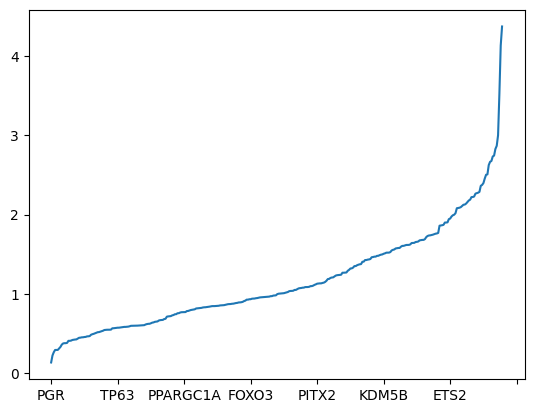

In [532]:
res_viper.var(0).sort_values().plot()

In [204]:
res_viper.var(0).describe()

count    340.000000
mean       1.049817
std        0.505341
min        0.223411
25%        0.682639
50%        0.939303
75%        1.295974
max        3.298919
dtype: float64

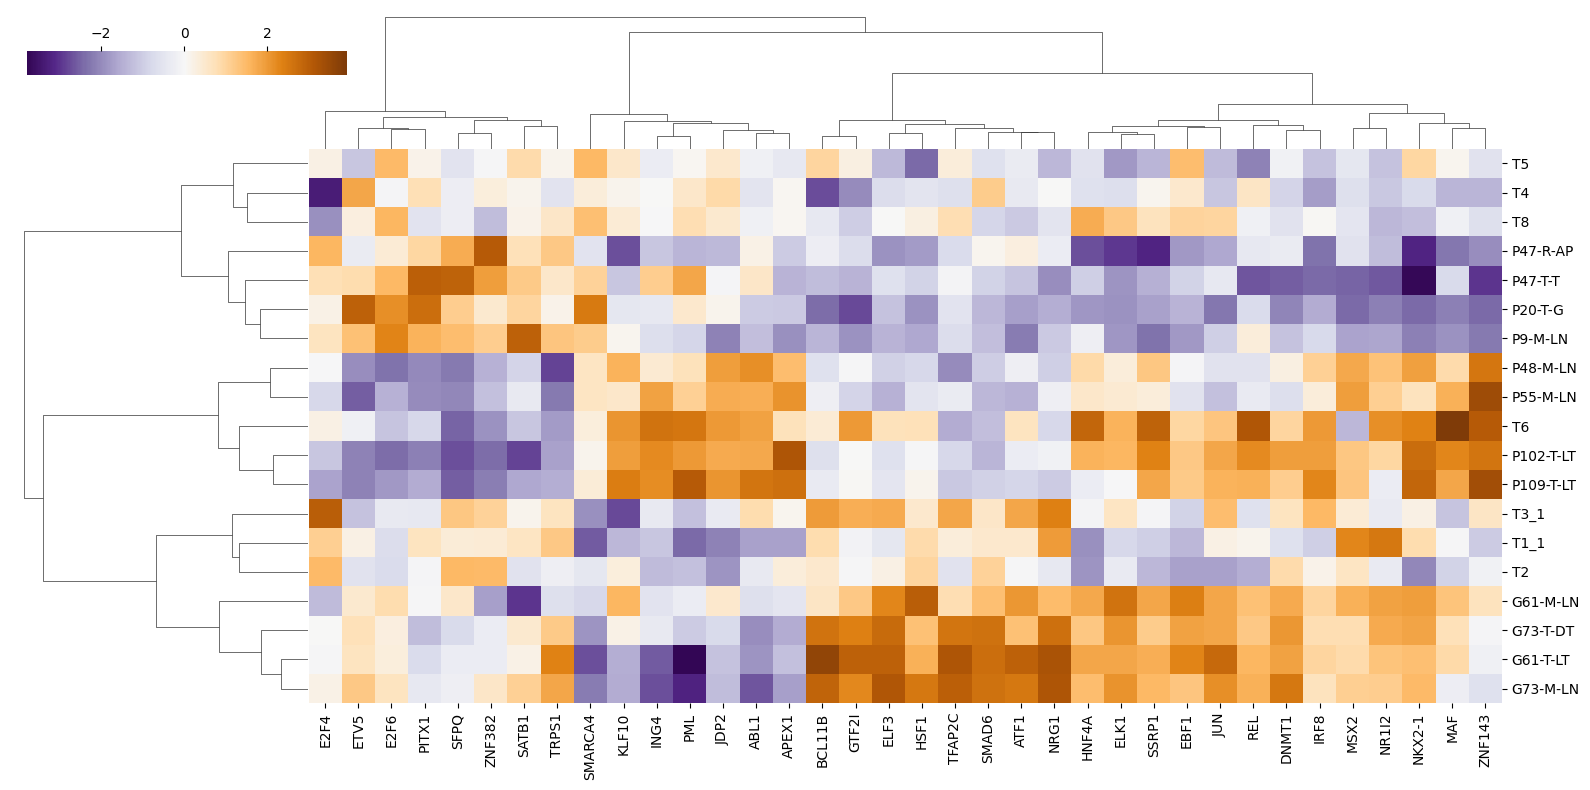

In [533]:
g = sns.clustermap(
    res_viper.loc[:,(res_viper.var(0)>2)],
    row_cluster=True,
    col_cluster=True,
    cmap="PuOr_r", #seismic
    standard_scale=None,
    z_score=None,
    center=0,
    method="ward",
    metric="euclidean",
    figsize=(16, 8),
    cbar_kws = dict(use_gridspec=False,location="top"),
    cbar_pos=(0.02, 0.90, 0.2, 0.03),
    # col_colors=color,
)